Importing the dependencies


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Analysis
* PIMA diabetes dataset

In [3]:
from pathlib import Path

candidate_paths = [
    Path("data/diabetes.csv"),
    Path("../data/diabetes.csv"),
]

for csv_path in candidate_paths:
    if csv_path.exists():
        diabetes_dataset = pd.read_csv(csv_path)
        print(f"Loaded dataset from: {csv_path}")
        break
else:
    raise FileNotFoundError("Could not find diabetes.csv in data/ or ../data/")

Loaded dataset from: ../data/diabetes.csv


In [4]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
diabetes_dataset.shape

(768, 9)

In [6]:
diabetes_dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
diabetes_dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### 0--> Non-diabetic and 
#### 1--> Diabetic

In [10]:
diabetes_dataset.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


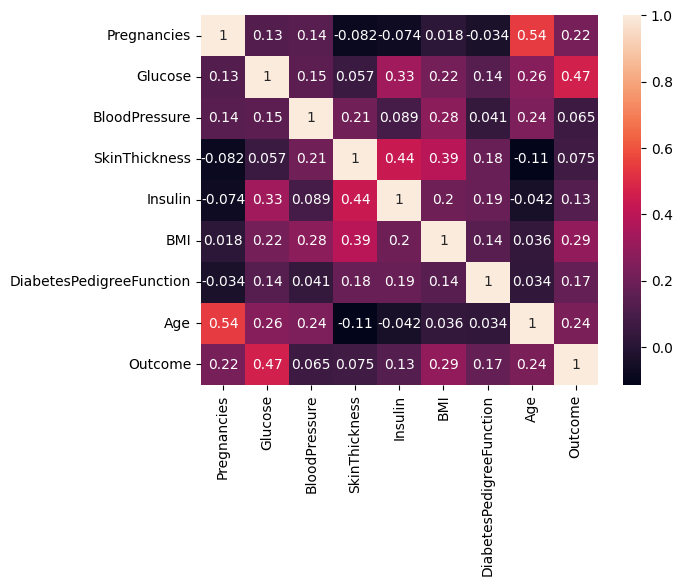

In [11]:
sns.heatmap(diabetes_dataset.corr(), annot=True)
plt.show()

/var/folders/4s/49pw6jxd1xj6523zzb2vrlzr0000gn/T/ipykernel_59681/1005867294.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=diabetes_dataset, palette="Set2")


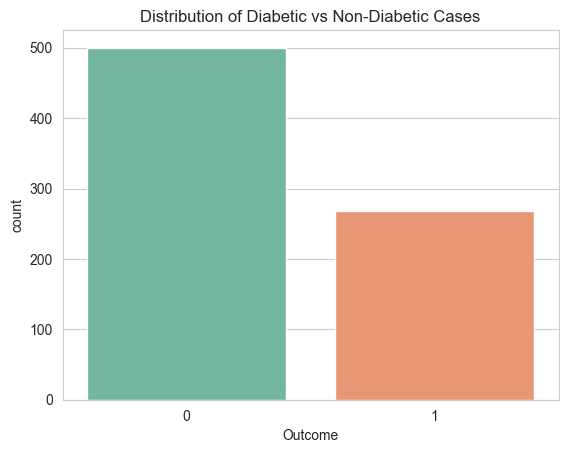

In [12]:
sns.set_style("whitegrid")
sns.countplot(x="Outcome", data=diabetes_dataset, palette="Set2")
plt.title("Distribution of Diabetic vs Non-Diabetic Cases")
plt.show()

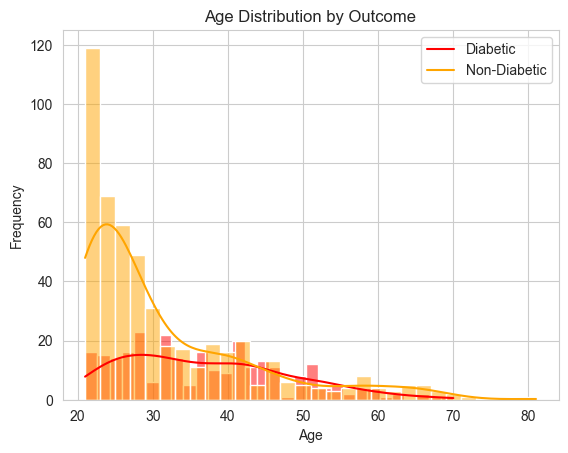

In [13]:
data_age1=diabetes_dataset[diabetes_dataset['Outcome']==1]
data_age2=diabetes_dataset[diabetes_dataset['Outcome']==0]

sns.histplot(data=data_age1['Age'], kde=True, bins=30,color='red')
sns.histplot(data=data_age2['Age'], kde=True, bins=30, color='orange')
plt.title('Age Distribution by Outcome')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['Diabetic', 'Non-Diabetic'])
plt.show()

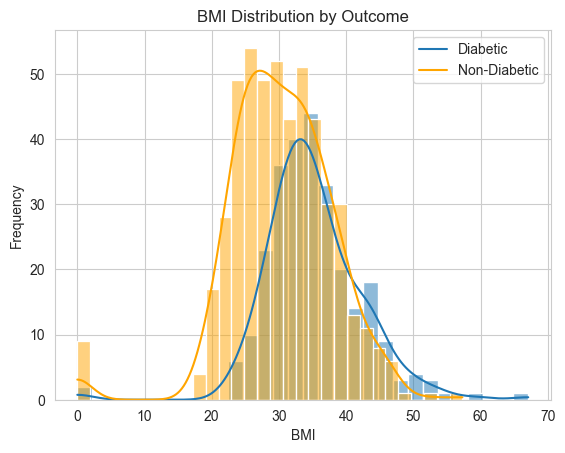

In [14]:
#BMI Distribution wrt Outcome
data_bmi1=diabetes_dataset[diabetes_dataset['Outcome']==1]
data_bmi2=diabetes_dataset[diabetes_dataset['Outcome']==0]
sns.histplot(data=data_bmi1['BMI'], kde=True, bins=30)
sns.histplot(data=data_bmi2['BMI'], kde=True, bins=30, color='orange')
plt.title('BMI Distribution by Outcome')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend(['Diabetic', 'Non-Diabetic'])
plt.show()

Separating Independent and Dependent

In [15]:
X=diabetes_dataset.drop(columns=['Outcome'])
y=diabetes_dataset['Outcome']

In [16]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [17]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Train Test Split

In [18]:
# Drop categorical columns for simpler preprocessing


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Data Standardization

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Preprocessing is done above with StandardScaler
# Models are trained on scaled numerical data

## Training The Model
#### Choosing the best model

In [22]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.7142857142857143
Recall: 0.5185185185185185
[[82 18]
 [26 28]]


In [23]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


RANDOM FOREST
Accuracy: 0.7467532467532467
Recall: 0.5925925925925926
[[83 17]
 [22 32]]


In [24]:
svm_model = SVC( random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("\nSVM (BASE)")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


SVM (BASE)
Accuracy: 0.7532467532467533
Recall: 0.6111111111111112
[[83 17]
 [21 33]]


##### Support vector machine has the best recall

## HYPERPARAMETER TUNING FOR SVM

In [25]:
# Instead of random splits, it ensures: Each fold has same % of class 0 and class 1 and Prevents biased training (very important when dataset is imbalanced)
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
from sklearn.metrics import make_scorer, f1_score

In [27]:
param_grid = {
    "C": [0.1,0.5, 1,5, 10],
    "gamma": [0.001, 0.01,0.05, 0.1],
    "kernel": ["rbf"],
    "class_weight": [ "balanced"]
}

svm_model = SVC()

grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    #verbose=0,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.5, 'class_weight': 'balanced', 'gamma': 0.05, 'kernel': 'rbf'}


In [28]:
print("\nBest Cross-Validation Score:", grid_search.best_score_)
y_pred = grid_search.predict(X_test)

print("\n===== FINAL SVM MODEL =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall (IMPORTANT):", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Best Cross-Validation Score: 0.6816071718145589

===== FINAL SVM MODEL =====
Accuracy: 0.7402597402597403
Recall (IMPORTANT): 0.7407407407407407
Precision: 0.6060606060606061

Confusion Matrix:
[[74 26]
 [14 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       100
           1       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



In [29]:
# Sample prediction with numerical features only
input_data = np.array([4, 110, 92, 0, 0, 37.6, 0.191, 30])
input_data_reshaped = input_data.reshape(1, -1)
input_data_scaled = scaler.transform(input_data_reshaped)
print("\nInput Data (Scaled):", input_data_scaled)
prediction = grid_search.predict(input_data_scaled)
print("\nPrediction for input data:", prediction[0])
if prediction[0] == 0:
    print("The person is not diabetic.")
else:    print("The person is diabetic.")


Input Data (Scaled): [[ 0.05459296 -0.3459224   1.22675155 -1.31138021 -0.73076636  0.71632576
  -0.86788263 -0.28471812]]

Prediction for input data: 0
The person is not diabetic.


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Built a diabetes prediction model using SVM and other ML algorithms, optimizing for high recall to minimize false negatives in medical diagnosis. Performed data preprocessing, feature scaling, and hyperparameter tuning, achieving ~72–75% recall with balanced accuracy.

Optimized diabetes prediction model using F1-score tuning, improving recall to ~74% while maintaining balanced accuracy and precision.

In [30]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(grid_search, MODEL_DIR / "diabetes_model.pkl")
joblib.dump(scaler, MODEL_DIR / "diabetes_scaler.pkl")

['../models/diabetes_scaler.pkl']